In [1]:
# dataset of CV in IT
import pandas as pd
df1 = pd.read_csv("C:/Users/Админ/Downloads/resumes_database.csv")
df1.head()

,pair_id,address,career_objective,skills,educational_institution_name,degree_names,passing_years,educational_results,result_types,major_field_of_studies,...,extra_curricular_organization_names,extra_curricular_organization_links,role_positions,languages,proficiency_levels,certification_providers,certification_skills,online_links,issue_dates,expiry_dates
0,1,NaN,Big data analytics working and database wareho...,"['Big Data', 'Hadoop', 'Hive', 'Python', 'Mapr...",['The Amity School of Engineering & Technology...,['B.Tech'],['2019'],['N/A'],[None],['Electronics'],...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,NaN,Fresher looking to join as a data analyst and ...,"['Data Analysis', 'Data Analytics', 'Business ...","['Delhi University - Hansraj College', 'Delhi ...","['B.Sc (Maths)', 'M.Sc (Science) (Statistics)']","['2015', '2018']","['N/A', 'N/A']","['N/A', 'N/A']","['Mathematics', 'Statistics']",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,3,NaN,NaN,"['Software Development', 'Machine Learning', '...","['Birla Institute of Technology (BIT), Ranchi']",['B.Tech'],['2018'],['N/A'],['N/A'],['Electronics/Telecommunication'],...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,4,NaN,To obtain a position in a fast-paced business ...,"['accounts payables', 'accounts receivables', ...","['Martinez Adult Education, Business Training ...",['Computer Applications Specialist Certificate...,['2008'],[None],[None],['Computer Applications'],...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,5,NaN,Professional accountant with an outstanding wo...,"['Analytical reasoning', 'Compliance testing k...",['Kent State University'],['Bachelor of Business Administration'],[None],['3.84'],[None],['Accounting'],...,"['Ohio Society of CPAs', 'Beta Alpha Psi', 'Go...","[None, None, None, None]","[None, None, None, None]",NaN,NaN,['Ohio Notary Public'],[None],[None],[None],"['February 15, 2021']"


In [3]:
print(df1.isnull().sum())

pair_id                                   0
address                                8760
career_objective                       4804
skills                                   56
educational_institution_name             84
degree_names                             84
passing_years                            84
educational_results                      84
result_types                             84
major_field_of_studies                   84
professional_company_names               84
company_urls                             84
start_dates                              84
end_dates                                84
related_skils_in_job                     84
positions                                84
locations                                84
responsibilities                          0
extra_curricular_activity_types        6118
extra_curricular_organization_names    6118
extra_curricular_organization_links    6118
role_positions                         6118
languages                       

In [5]:
cols = [
    "career_objective",
    "skills",
    "responsibilities",
    "positions",
    "degree_names",
    "major_field_of_studies"
]

df1 = df1[cols]

In [7]:
print(df1.isnull().sum())

print(df1.dtypes)

career_objective          4804
skills                      56
responsibilities             0
positions                   84
degree_names                84
major_field_of_studies      84
dtype: int64
career_objective          object
skills                    object
responsibilities          object
positions                 object
degree_names              object
major_field_of_studies    object
dtype: object


In [9]:
df1["career_objective"] = df1["career_objective"].fillna("")
df1["skills"] = df1["skills"].fillna("")
df1["positions"] = df1["positions"].fillna("")
df1["degree_names"] = df1["degree_names"].fillna("")
df1["major_field_of_studies"] = df1["major_field_of_studies"].fillna("")

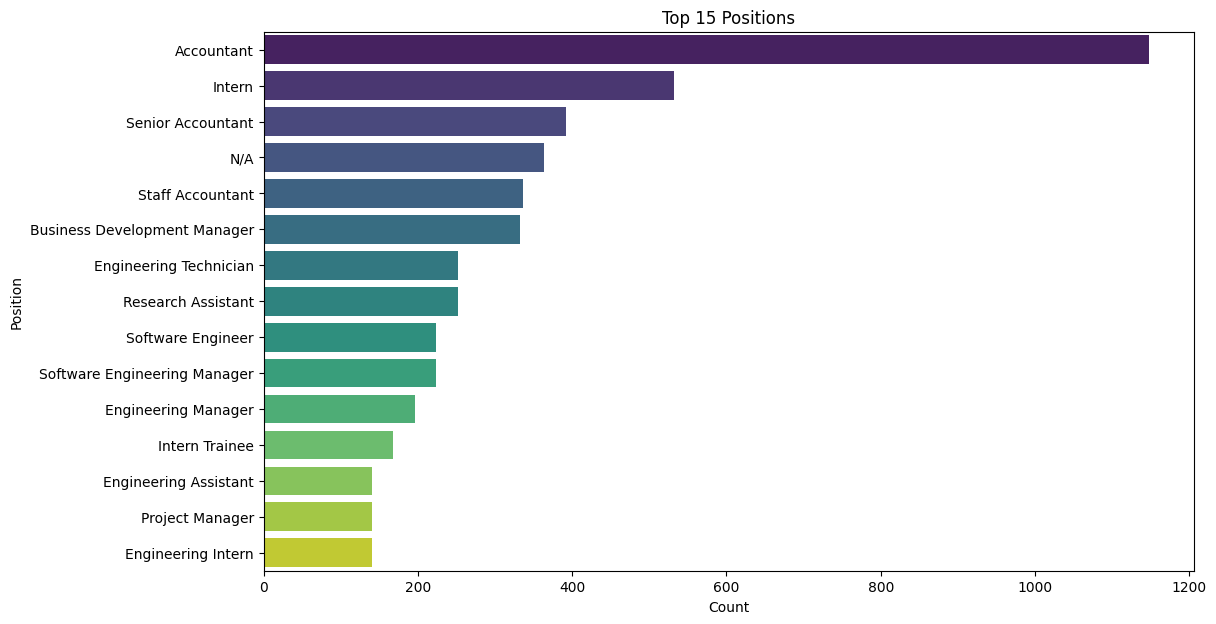

In [11]:
import ast
from collections import Counter
import seaborn as sns
import matplotlib.pyplot as plt

def extract_positions(x):
    try:
        items = ast.literal_eval(str(x))
        return [item.strip() for item in items]
    except:
        return []

all_positions = []

for row in df1["positions"]:
    all_positions.extend(extract_positions(row))

top_positions = Counter(all_positions).most_common(15)

positions, counts = zip(*top_positions)

plt.figure(figsize=(12,7))

sns.barplot(
    x=list(counts),
    y=list(positions),
    hue=list(positions),
    palette="viridis",
    legend=False
)

plt.title("Top 15 Positions")
plt.xlabel("Count")
plt.ylabel("Position")

plt.show()

In [13]:
df1[["skills", "responsibilities", "positions"]].sample(5)

,skills,responsibilities,positions
4491,"['Python', 'Scikit Learn', 'Keras', 'Tensorflo...",Internal Audit Assistance\nVoucher & Bill Veri...,['Software Developer and Analyst Trainee']
6382,"['streamline', 'approach', 'balance sheet', 'b...",Open-Source Technologies\nCI/CD Culture & Tool...,"['VP of Business Development', 'Co-Founder VP ..."
2328,"['Executive Decision Maker', 'Process Design &...",Generative AI Development\nEvolutionary Comput...,"['Engineering Manager', 'Project Manager', 'Se..."
6744,"['Data Manipulation', 'Data Mining', 'Python',...","Trade Marketing Executive\nBrand Visibility, S...","['Junior Data Evangelist', 'Software Developer..."
980,"['Microsoft Office (Word, Excel, Power Point, ...",Technical Support\nTroubleshooting\nCollaborat...,"['Staff Accountant', 'Independent Accounting C..."


In [15]:
# Converts columns containing string-represented lists into space-separated text 
# to make them compatible with text cleaning and vectorization.
import ast
def clean_list(x):
    try:
        value = ast.literal_eval(str(x))
        if isinstance(value, list):
            return " ".join(map(str, value))
        return str(value)
    except:
        return str(x)

list_columns = [
    "skills",
    "positions",
    "degree_names",
    "major_field_of_studies"
]

for col in list_columns:
    df1[col] = df1[col].apply(clean_list)


In [17]:
# Standardizes text by converting to lowercase, removing special characters, 
# and handling empty placeholders to prepare the data for NLP vectorization.
import re

def clean_text(text):
    text = str(text).lower()
    # remove useless placeholders
    if text in ["n/a", "na", "none", "unknown", "null"]:
        return ""
    text = re.sub(r"[^a-zA-Z0-9+#.\- ]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

text_columns = [
    "career_objective",
    "skills",e 
    "responsibilities",
    "positions",
    "degree_names",
    "major_field_of_studies"
]

for col in text_columns:
    df1[col] = df1[col].apply(clean_text)

In [19]:
df1["resume_text"] = (
    df1["career_objective"] + " " +
    df1["skills"] + " " +
    df1["responsibilities"] + " " +
    df1["positions"] + " " +
    df1["degree_names"] + " " +
    df1["major_field_of_studies"]
)

In [21]:
# dataset with different resume in different industries
df2 = pd.read_csv("C:/Users/Админ/Downloads/resumes_diverse_21_spheres.csv")
df2

,career_objective,skills,responsibilities,positions,degree_names,major_field_of_studies,resume_text
0,creative marketing professional aiming to enha...,social media management crm copywriting hubspo...,increased website traffic by 30% collaborated ...,marketing,b.s.,marketing,creative marketing professional aiming to enha...
1,compassionate healthcare professional seeking ...,clinical ehr first aid triage bls cpr hipaa,updated electronic health records accurately e...,healthcare,d.o.,medicine,compassionate healthcare professional seeking ...
2,innovative mechanical engineer seeking to desi...,matlab autocad ansys manufacturing quality con...,conducted finite element analysis (fea) perfor...,mechanical engineer,b.e.,aerospace engineering,innovative mechanical engineer seeking to desi...
3,results-driven sales manager looking to scale ...,presentation team leadership salesforce crm b2...,negotiated contracts with key clients managed ...,sales manager,mba,marketing,results-driven sales manager looking to scale ...
4,enthusiastic retail professional seeking to de...,merchandising sales leadership visual merchand...,trained new retail associates designed visual ...,retail,associate,business,enthusiastic retail professional seeking to de...
...,...,...,...,...,...,...,...
10495,looking for a dynamic customer service role to...,problem solving time management crm zendesk ac...,resolved customer inquiries via phone and emai...,customer service,high school,business,looking for a dynamic customer service role to...
10496,innovative mechanical engineer seeking to desi...,solidworks matlab autocad ansys thermodynamics,designed mechanical components using cad softw...,mechanical engineer,m.s.,mechanical engineering,innovative mechanical engineer seeking to desi...
10497,looking to apply my financial modeling experti...,corporate finance financial modeling valuation...,assisted in the annual budgeting process devel...,financial analyst,b.s.,accounting,looking to apply my financial modeling experti...
10498,looking for a design role to utilize my skills...,adobe illustrator ui/ux creativity branding ph...,collaborated with the marketing team on ad cam...,graphic designer,associate,visual communications,looking for a design role to utilize my skills...


In [23]:
# mix 2 datasets together
df = pd.concat([df1, df2], ignore_index=True)
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20044 entries, 0 to 20043
Data columns (total 7 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   career_objective        20044 non-null  object
 1   skills                  20044 non-null  object
 2   responsibilities        20044 non-null  object
 3   positions               20044 non-null  object
 4   degree_names            20044 non-null  object
 5   major_field_of_studies  20044 non-null  object
 6   resume_text             20044 non-null  object
dtypes: object(7)
memory usage: 1.1+ MB
None


In [25]:
df["skills_len"] = df["skills"].apply(lambda x: len(x.split()))
df["responsibilities_len"] = df["responsibilities"].apply(lambda x: len(x.split()))

In [27]:
df = df[df["skills_len"] > 0]

In [29]:
df[["skills", "responsibilities", "positions"]].sample(5)

,skills,responsibilities,positions
13792,project management autocad manufacturing solid...,collaborated with manufacturing teams conducte...,mechanical engineer
16881,critical thinking contract drafting legal rese...,ensured corporate compliance with regulations ...,legal
10228,stakeholder management requirements gathering ...,created process flow diagrams facilitated comm...,business analyst
8791,software development data science data analysi...,mikrotik router configuration olt device setup...,intern
1641,c++ python c software developer prediction mod...,mikrotik router configuration olt device setup...,developer engineer


In [31]:
df[["skills_len", "responsibilities_len"]].describe()

,skills_len,responsibilities_len
count,19932.000000,19932.000000
mean,23.729029,21.838350
std,30.284656,8.607098
min,5.000000,7.000000
25%,10.000000,17.000000
50%,14.000000,20.000000
75%,23.000000,24.000000
max,373.000000,60.000000


<Axes: >

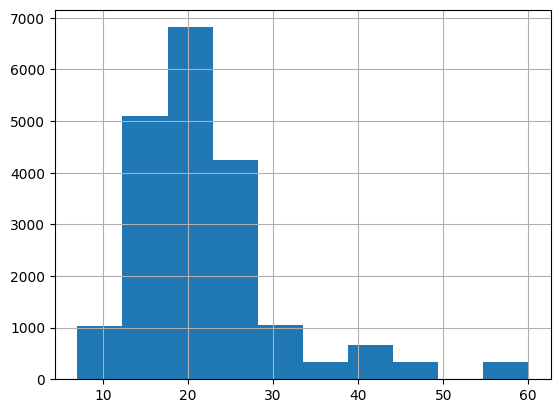

In [33]:
import matplotlib.pyplot as plt

df["responsibilities_len"].hist()

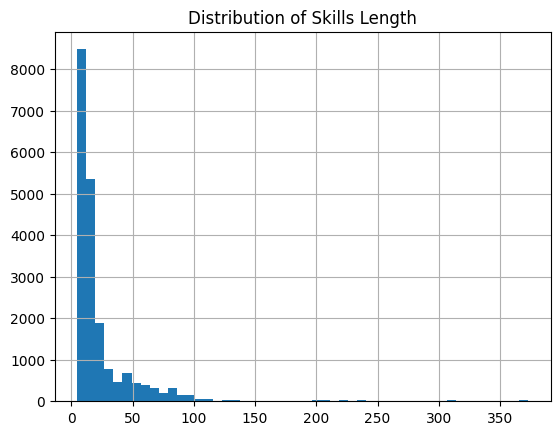

In [35]:
df["skills_len"].hist(bins=50)
plt.title("Distribution of Skills Length")
plt.show()

In [37]:
df = df[df["skills_len"] > 0]
df = df[df["skills_len"] < 150]

In [41]:
from collections import Counter

all_words = " ".join(df["skills"]).split()
Counter(all_words).most_common(20)

[('management', 11233),
 ('data', 10792),
 ('analysis', 6888),
 ('learning', 5682),
 ('python', 4408),
 ('and', 4328),
 ('excel', 4218),
 ('machine', 3946),
 ('microsoft', 3808),
 ('office', 3753),
 ('financial', 3308),
 ('sql', 2964),
 ('development', 2954),
 ('sales', 2896),
 ('communication', 2860),
 ('project', 2844),
 ('business', 2736),
 ('leadership', 2526),
 ('inventory', 2282),
 ('accounting', 2261)]

In [43]:
df["degree_names"].nunique()

190

In [45]:
df["positions"].nunique()

305

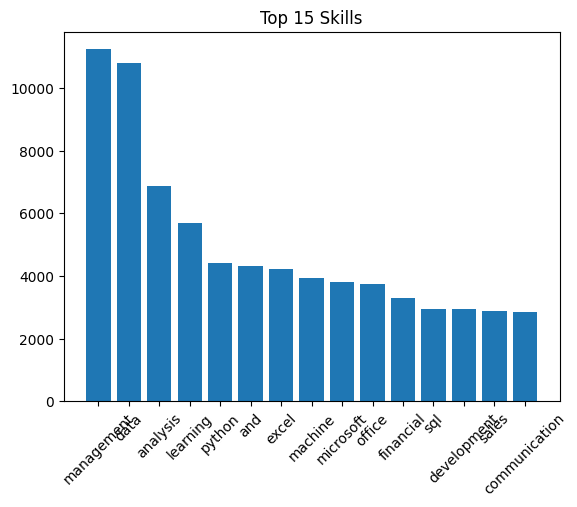

In [49]:
# Extracts the most frequent skills from the dataset and visualizes them in a bar chart.
from collections import Counter
import matplotlib.pyplot as plt

all_skills = " ".join(df["skills"]).split()

top_skills = Counter(all_skills).most_common(15)

words, counts = zip(*top_skills)

plt.figure()
plt.bar(words, counts)
plt.xticks(rotation=45)
plt.title("Top 15 Skills")
plt.show()

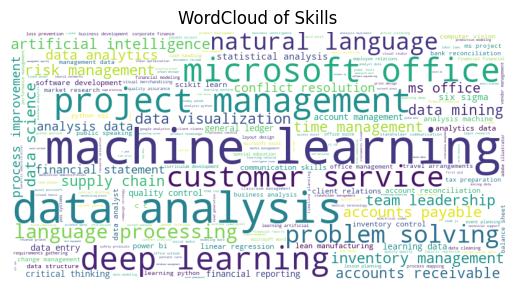

In [51]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# all skills in one text
text = " ".join(df["skills"])

# create cloude
wordcloud = WordCloud(
    width=800,
    height=400,
    background_color="white"
).generate(text)

plt.figure()
plt.imshow(wordcloud)
plt.axis("off")
plt.title("WordCloud of Skills")
plt.show()

In [53]:
# final shape
print("Final dataset shape:", df.shape)
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

# check columns
print("\nColumns:")
print(df.columns.tolist())

# check missing values
print("\nMissing values:")
print(df.isnull().sum())

# check empty strings
print("\nEmpty values:")
print((df == "").sum())

# check sample
df.head()

Final dataset shape: (19764, 9)
Number of rows: 19764
Number of columns: 9

Columns:
['career_objective', 'skills', 'responsibilities', 'positions', 'degree_names', 'major_field_of_studies', 'resume_text', 'skills_len', 'responsibilities_len']

Missing values:
career_objective          0
skills                    0
responsibilities          0
positions                 0
degree_names              0
major_field_of_studies    0
resume_text               0
skills_len                0
responsibilities_len      0
dtype: int64

Empty values:
career_objective          4608
skills                       0
responsibilities             0
positions                  140
degree_names                56
major_field_of_studies     784
resume_text                  0
skills_len                   0
responsibilities_len         0
dtype: int64


,career_objective,skills,responsibilities,positions,degree_names,major_field_of_studies,resume_text,skills_len,responsibilities_len
0,big data analytics working and database wareho...,big data hadoop hive python mapreduce spark ja...,technical support troubleshooting collaboratio...,big data analyst,b.tech,electronics,big data analytics working and database wareho...,28,15
1,fresher looking to join as a data analyst and ...,data analysis data analytics business analysis...,machine learning leadership cross-functional c...,business analyst,b.sc maths m.sc science statistics,mathematics statistics,fresher looking to join as a data analyst and ...,16,46
2,,software development machine learning deep lea...,trade marketing executive brand visibility sal...,software developer machine learning engineer,b.tech,electronics telecommunication,software development machine learning deep le...,20,17
3,to obtain a position in a fast-paced business ...,accounts payables accounts receivables account...,apparel sourcing quality garment sourcing reli...,accountant accounts receivable clerk mortgage ...,computer applications specialist certificate p...,computer applications,to obtain a position in a fast-paced business ...,47,10
4,professional accountant with an outstanding wo...,analytical reasoning compliance testing knowle...,ios lifecycle requirement analysis native fram...,staff accountant senior accountant tax analyst...,bachelor of business administration,accounting,professional accountant with an outstanding wo...,55,30


In [55]:
# text length after cleaning
df["resume_text_len"] = df["resume_text"].apply(lambda x: len(str(x).split()))

print(df["resume_text_len"].describe())

# check if there are still bad placeholders
bad_values = ["n/a", "na", "none", "unknown", "null"]

for col in df.columns:
    if df[col].dtype == "object":
        count_bad = df[col].astype(str).str.lower().isin(bad_values).sum()
        print(col, "bad values:", count_bad)

count    19764.000000
mean        66.922941
std         33.588341
min         22.000000
25%         45.000000
50%         53.000000
75%         80.000000
max        355.000000
Name: resume_text_len, dtype: float64
career_objective bad values: 0
skills bad values: 0
responsibilities bad values: 0
positions bad values: 0
degree_names bad values: 0
major_field_of_studies bad values: 0
resume_text bad values: 0


In [57]:
bad_values = ["n/a", "na", "none", "unknown", "null"]

df["major_field_of_studies"] = df["major_field_of_studies"].replace(
    bad_values,
    ""
)

In [59]:
final_cols = [
    "career_objective",
    "skills",
    "responsibilities",
    "positions",
    "degree_names",
    "major_field_of_studies",
    "resume_text"
]

df_final = df[final_cols]

In [61]:
df_final.to_csv(
    "resumes_cleaned.csv",
    index=False
)

print("Dataset saved successfully!")

Dataset saved successfully!


In [205]:
# ADZUNA
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

df_jobs = pd.read_csv(
    "C:/Users/Админ/Downloads/adzuna_diverse_jobs_with_medical.csv", 
    skiprows=1, 
    sep=';'
)

print(df_jobs.columns)
print(df_jobs.head())

Index(['job_title', 'company_name', 'category', 'description', 'location',
       'salary_min', 'salary_max', 'contract_time', 'contract_type', 'created',
       'job_url', 'required_skills', 'required_degree'],
      dtype='object')
           job_title     company_name category  \
0  Software Engineer  Lockheed Martin  IT Jobs   
1  Software Engineer  Lockheed Martin  IT Jobs   
2  Software Engineer  Lockheed Martin  IT Jobs   
3  Software Engineer  Lockheed Martin  IT Jobs   
4  Software Engineer  Lockheed Martin  IT Jobs   

                                         description  \
0  Job Description: What We're Doing Lockheed Mar...   
1  Job Description: What We're Doing Lockheed Mar...   
2  Job Description: What We're Doing Lockheed Mar...   
3  Job Description: What We're Doing Lockheed Mar...   
4  Job Description: What We're Doing Lockheed Mar...   

                                        location  salary_min  salary_max  \
0  US, New Jersey, Burlington County, Moorestown   1

In [207]:
df_jobs.shape

(10494, 13)

In [209]:
df_jobs.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10494 entries, 0 to 10493
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   job_title        10494 non-null  object 
 1   company_name     10494 non-null  object 
 2   category         10494 non-null  object 
 3   description      10494 non-null  object 
 4   location         10494 non-null  object 
 5   salary_min       10494 non-null  float64
 6   salary_max       10493 non-null  float64
 7   contract_time    3794 non-null   object 
 8   contract_type    95 non-null     object 
 9   created          10494 non-null  object 
 10  job_url          10494 non-null  object 
 11  required_skills  5749 non-null   object 
 12  required_degree  886 non-null    object 
dtypes: float64(2), object(11)
memory usage: 1.0+ MB


In [211]:
print(df_jobs.isnull().sum())

job_title              0
company_name           0
category               0
description            0
location               0
salary_min             0
salary_max             1
contract_time       6700
contract_type      10399
created                0
job_url                0
required_skills     4745
required_degree     9608
dtype: int64


In [213]:
import re

def clean_text(text):
    if not isinstance(text, str):
        return ""
    # lowercase
    text = text.lower()
    # Noise Removal: Strips punctuation and special characters, keeping only alphanumeric text
    text = re.sub(r'[^a-z0-9\s]', ' ', text)
    # Whitespace Normalization: Converts multiple spaces/newlines into a single space
    # and removes spaces from the very beginning and end of the string
    text = re.sub(r'\s+', ' ', text).strip()
    return text

In [215]:
df_jobs['required_skills'] = df_jobs['required_skills'].fillna('not specified')
df_jobs['description'] = df_jobs['description'].fillna('')

In [217]:
df_jobs.duplicated().sum()

0

In [219]:
df_jobs["job_text"] = (
    df_jobs["job_title"] + " " + 
    df_jobs["description"] + " " + 
    df_jobs["required_skills"]
)

#  clean_text
df_jobs["job_text_clean"] = df_jobs["job_text"].apply(clean_text)

print(df_jobs["job_text_clean"].head(1)) 

0    software engineer job description what we re d...
Name: job_text_clean, dtype: object


In [221]:
final_columns = [
    'job_title', 
    'company_name', 
    'category', 
    'location', 
    'salary_min', 
    'salary_max',
    'description',    
    'required_skills', 
    'job_text_clean'   
]


df_jobs_final = df_jobs[final_columns].copy()

In [223]:
df_jobs_final["description_len"] = df_jobs["description"].fillna("").apply(lambda x: len(str(x).split()))
df_jobs_final["title_len"] = df_jobs["job_title"].fillna("").apply(lambda x: len(str(x).split()))

In [225]:
df_jobs_final[["title_len", "description_len"]].describe()

,title_len,description_len
count,10494.000000,10494.000000
mean,3.731656,74.225176
std,2.218769,6.825422
min,1.000000,14.000000
25%,2.000000,70.000000
50%,3.000000,75.000000
75%,5.000000,79.000000
max,13.000000,98.000000


In [227]:
from sklearn.feature_extraction.text import TfidfVectorizer, ENGLISH_STOP_WORDS

# our own stopwords
my_stops = list(ENGLISH_STOP_WORDS) + ['job', 'description', 'work', 'experience', 'team', 'working', 'specified', '000']

vectorizer = TfidfVectorizer(max_features=1000, stop_words=my_stops)

# train and get matrix
tfidf_matrix = vectorizer.fit_transform(df_jobs_final['job_text_clean'])

# calculate avarage wight of words
import numpy as np
weights = np.asarray(tfidf_matrix.mean(axis=0)).ravel()
words = vectorizer.get_feature_names_out()

top_words = pd.DataFrame({'word': words, 'weight': weights}).sort_values(by='weight', ascending=False).head(20)

print(top_words)

           word    weight
626  operations  0.035235
563   marketing  0.030998
810       sales  0.030523
251        data  0.030496
558     manager  0.030115
67      analyst  0.029698
799        role  0.027552
830     service  0.025673
129    business  0.025667
378   financial  0.024696
888     support  0.024644
244    customer  0.024265
518  leadership  0.022761
193     company  0.021285
689    position  0.021057
853   solutions  0.020139
261     defense  0.019969
557  management  0.019957
827      senior  0.019452
993       world  0.019342


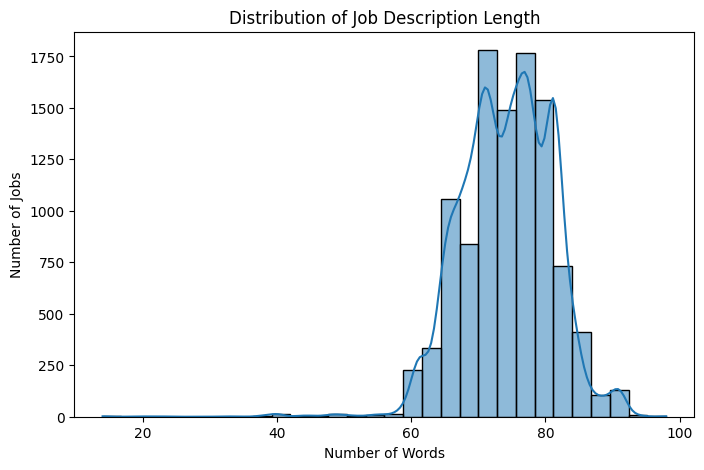

In [229]:
plt.figure(figsize=(8, 5))
sns.histplot(df_jobs_final["description_len"], bins=30, kde=True)

plt.title("Distribution of Job Description Length")
plt.xlabel("Number of Words")
plt.ylabel("Number of Jobs")

plt.show()

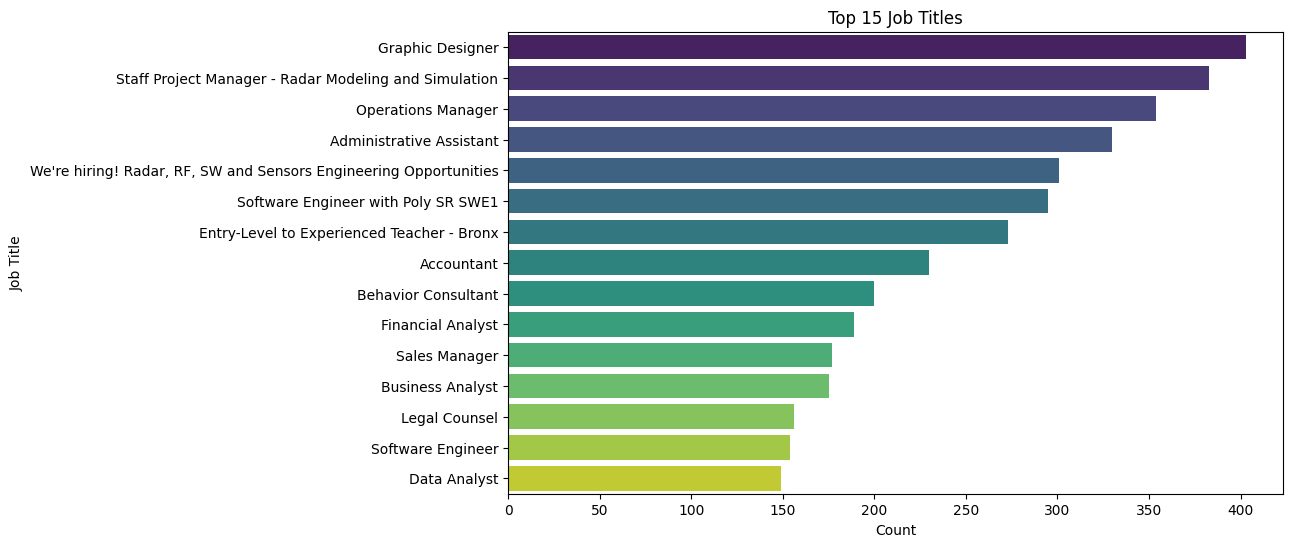

In [231]:
top_titles = df_jobs_final["job_title"].value_counts().head(15)

plt.figure(figsize=(10, 6))
sns.barplot(
    x=top_titles.values,
    y=top_titles.index,
    hue=top_titles.index,
    palette="viridis",
    legend=False
)

plt.title("Top 15 Job Titles")
plt.xlabel("Count")
plt.ylabel("Job Title")

plt.show()

In [233]:
df_jobs[["salary_min", "salary_max"]].describe()

,salary_min,salary_max
count,10494.000000,10493.000000
mean,97784.688002,100128.573134
std,54735.382826,54441.322538
min,0.000000,1.000000
25%,60000.000000,63733.320000
50%,80000.000000,83715.170000
75%,116074.842500,118640.950000
max,455449.160000,500000.000000


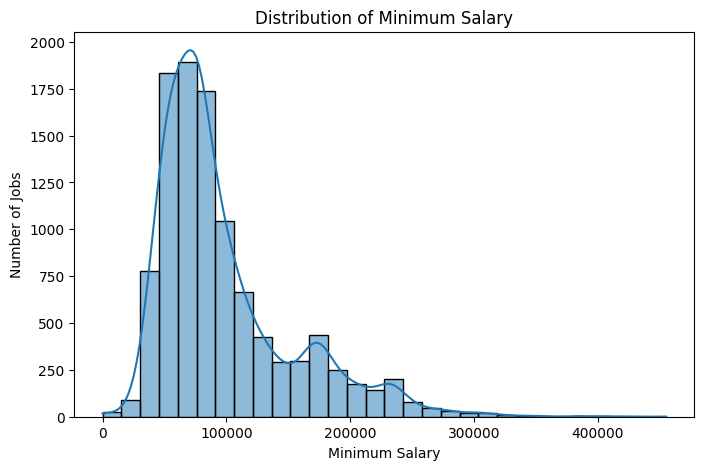

In [235]:
plt.figure(figsize=(8, 5))
sns.histplot(df_jobs["salary_min"].dropna(), bins=30, kde=True)

plt.title("Distribution of Minimum Salary")
plt.xlabel("Minimum Salary")
plt.ylabel("Number of Jobs")

plt.show()

In [237]:
df_jobs["location"].value_counts().head(15)

location
US                                                       136
US, New York, New York City, Manhattan, Grand Central     94
US, Georgia, Fulton County, Atlanta                       76
US, Tennessee, Davidson County, Nashville                 68
US, Arizona, Maricopa County, Phoenix                     64
US, North Carolina, Mecklenburg County, Charlotte         58
US, Massachusetts, Suffolk County, Boston                 51
US, Minnesota, Hennepin County, Minneapolis               47
US, Colorado, Denver, Glendale                            42
US, New York, New York City                               37
US, California, San Diego County, San Diego               31
US, Oklahoma, Oklahoma County, Oklahoma City              31
US, California, Los Angeles County, Pico Heights          31
US, Washington, King County, International                29
US, Indiana, Marion County, Uptown                        29
Name: count, dtype: int64

In [243]:
# Final cols withot description_lens etc.
cols_to_keep = [
    'job_title', 
    'company_name', 
    'category', 
    'location', 
    'salary_min', 
    'salary_max',
    'description',      
    'required_skills', 
    'job_text_clean'    
]


df_jobs_final = df_jobs[cols_to_keep].copy()

# Savw cleaned csv
df_jobs_final.to_csv("adzuna_cleaned_final_.csv", index=False, sep=';', encoding='utf-8-sig')

print("Файл сохранен успешно! Лишние колонки (len) удалены, описание добавлено.")

Файл сохранен успешно! Лишние колонки (len) удалены, описание добавлено.
